## Imports, global variables

In [1]:
import kszx
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 2-d flat sky, side length 2 radians, 2048^2 pixels
box = kszx.Box(npix=(2048,2048), pixsize=2/2048)
print(box)

Box(
    npix = [2048 2048],
    pixsize = 0.0009765625,
    boxsize = [2. 2.],
    kfund = [3.14159265 3.14159265],
    knyq = 3216.990877275948,
    lpos = [0.00048828 0.00048828],
    cpos = [1. 1.],
    rpos = [1.99951172 1.99951172],
)



In [3]:
print(f'Note: pixel-space maps are represented as real-valued arrays with shape {box.real_space_shape}')
print(f'Fourier-space maps are represented as complex-valued arrays with shape {box.fourier_space_shape}')

Note: pixel-space maps are represented as real-valued arrays with shape (np.int64(2048), np.int64(2048))
Fourier-space maps are represented as complex-valued arrays with shape (np.int64(2048), np.int64(1025))


In [4]:
# The Cosmology constructor runs CAMB and computes lensed Cls (cosmo.cltt_len)
cosmo = kszx.Cosmology('planck18+bao')
lmax = cosmo.lmax
print(f'{lmax=}')

Running CAMB
lmax=5000


In [5]:
# bl = beam transfer function for 7 arcmin beam
# (We'll use bl^2 C_l^{lensed} as the "signal" throughout)

fwhm_arcmin = 7
sigma_rad = (fwhm_arcmin * np.pi / 180 / 60) / np.sqrt(8 * np.log(2))
ls = np.arange(lmax + 1)
bl = np.exp(-0.5 * ls * (ls + 1) * sigma_rad**2)

In [6]:
# nl = noise power spectrum, units (uK)^2
# Scalar (constant in l)
uK_arcmin = 20.0
nl = (uK_arcmin * np.pi / 180 / 60)**2 

In [7]:
# Fourier-space maps (shape (8192,4097))
#  lmap = value of |l| at each Fourier mode (lx,ly)
#  clmap = value of (b_l^2 C_l^{lensed})

lmap = box.get_k()
clmap = np.interp(lmap, ls[2:], bl[2:]**2 * cosmo.cltt_len[2:], right=0)  # set to zero for l > lmax

print(f'{lmap.shape=} {clmap.shape=}')

lmap.shape=(2048, 1025) clmap.shape=(2048, 1025)


## Simulate Gaussian random map, estimate power spectrum, compare with theory spectrum

In [8]:
# The function kszx.simulate_white_noise(box, fourier=True) simulates
# a Gaussian Fourier-space map with C_l=1.

m = kszx.simulate_white_noise(box, fourier=True) * np.sqrt(clmap + nl)

In [9]:
# Estimate power spectrum in 100 l-bins

lbin_edges = np.linspace(0, 3000, 101)
cl_estimated = kszx.estimate_power_spectrum(box, m, lbin_edges)

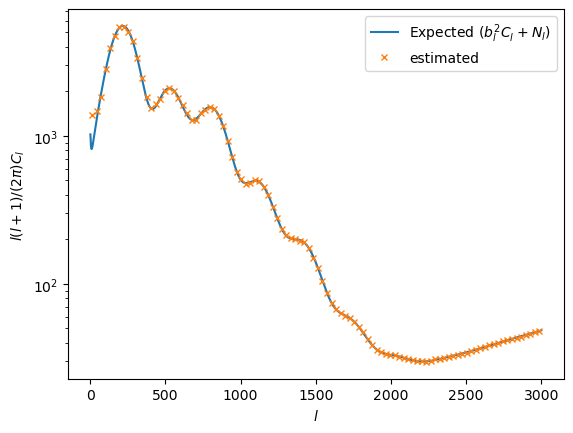

In [10]:
ls = np.arange(2,3001)
plt.plot(ls, ls*(ls+1)/(2*np.pi) * (bl[2:3001]**2 * cosmo.cltt_len[2:3001] + nl), label = r'Expected ($b_l^2 C_l^ + N_l$)')
    
lbin_centers = (lbin_edges[:-1] + lbin_edges[1:]) / 2.
plt.plot(lbin_centers, lbin_centers * (lbin_centers+1) * cl_estimated / (2*np.pi), marker='x', ms=4, ls='none', label='estimated')

plt.xlabel(r'$l$')
plt.ylabel(r'$l(l+1)/(2\pi) C_l$')
plt.yscale('log')
plt.legend()

## Lens reconstruction (untested, I might have screwed up!)

In [11]:
def _asymmetric_phihat0(x,y):
    """
    Given Fourier-space maps (x,y), returns Fourier-space map
    
      z(L) = int_{l1+l2=L} [(l1+l2).l1] C_{l1} x(l1) y(l2).
    
    This is a helper function for phihat() below, which defines an
    interface which is symmetric in (x,y).
    """

    # Write dot product as (l1+l2)_j (l1)_j.
    # Bring j-sum outside of integral, and compute each of the two
    # terms using the convolution theorem.

    yre = kszx.fft_c2r(box,y)  # Fourier-space -> real-space
    ret = np.zeros(box.fourier_space_shape, dtype=complex)

    for j in range(2):
        # Note that kszx.apply_partial_derivative() multiplies a
        # Fourier-space map by (i l_j).
        m = kszx.apply_partial_derivative(box, clmap * x, axis=j)
        m = kszx.fft_c2r(box, m)   # fourier->real
        m *= yre  # multiplication in real-space (= Fourier-space convolution)
        m = kszx.fft_r2c(box, m)   # real->fourier

        # Note minus sign here, to cancel two powers of (i) from the
        # two calls to kszx.apply_partial_derivative().
        ret -= kszx.apply_partial_derivative(box, m, axis=j)

    return ret


In [12]:
def phihat0(x, y=None):
    """
    Given Fourier-space maps (x,y), returns Fourier-space map

      phihat0(L) = (1/2) int_{l1+l2=L} f(l1,l2) x(l1) y(l2)

    where

      f(l1,l2) = [(l1+l2).l1] C_{l1}^{TT} + [(l1+l2).l2] C_{l2}^{TT}
    
    Note: phihat0(x) is equivalent to phihat0(x,x), but is ~2x faster.
    
    The most common case is x = (tilde T) = T(l) / C_l^{tot}
    """

    if y is None:
        return _asymmetric_phihat0(x,x)        
    return 0.5 * (_asymmetric_phihat0(x,y) + _asymmetric_phihat0(y,x))